Top 5 row: 
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
The missing values: 
school        0
sex           0
age           0
address

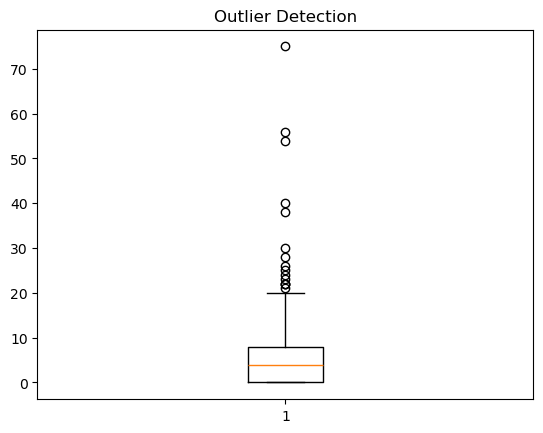

Check for noisy data: 


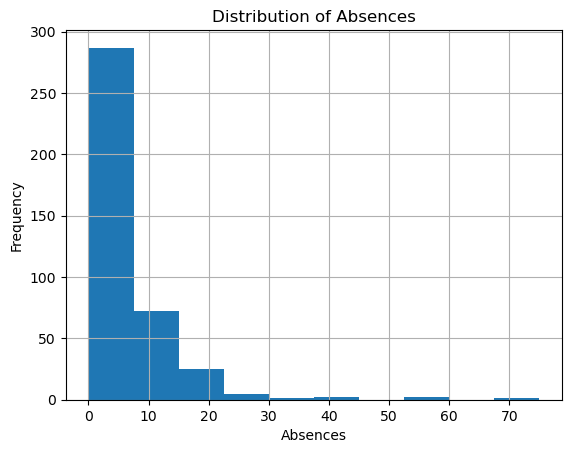

Check for normalization: 


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"D:\AIML_PBL_dataset\student_data.csv")

print("Top 5 row: ")
print(df.head())

print("The missing values: ")
print(df.isnull().sum())

print("The data type: ")
print(df.info())

plt.boxplot(df["absences"])
plt.title("Outlier Detection")
plt.show()

print("Check for noisy data: ")
df["absences"].hist()
plt.title("Distribution of Absences")
plt.xlabel("Absences")
plt.ylabel("Frequency")
plt.show()

print("Check for normalization: ")
df.describe()


In [5]:
df_final=df.copy()

df_final['Student_ID'] = range(1, len(df) + 1)                              

#studytime(categorical) level 1-4
df_final['Study_Hours'] = df_final['studytime'] * 2

#each absence=2% drop
df_final['Attendance'] = 100 - (df_final['absences'] * 2)

#health(categorical) level 1-5
df_final['Sleep_Hours'] = df_final['health'] + 4

df_final['Previous_Marks'] = df_final['G2']

df_final['Assignments_Completed'] = 10 - df_final['failures']

df_final['Distraction_Time'] = df_final['goout'] + df_final['freetime']

df_final['Current_Score'] = df_final['G3']

df_final['Target_Score'] = df_final['Current_Score'] + 10

df_final=df_final[['Student_ID', 'Study_Hours', 'Attendance', 'Sleep_Hours', 
                   'Previous_Marks', 'Assignments_Completed', 'Distraction_Time', 'Current_Score', 'Target_Score']]

print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Student_ID             395 non-null    int64
 1   Study_Hours            395 non-null    int64
 2   Attendance             395 non-null    int64
 3   Sleep_Hours            395 non-null    int64
 4   Previous_Marks         395 non-null    int64
 5   Assignments_Completed  395 non-null    int64
 6   Distraction_Time       395 non-null    int64
 7   Current_Score          395 non-null    int64
 8   Target_Score           395 non-null    int64
dtypes: int64(9)
memory usage: 27.9 KB
None


In [6]:
#replace values with missing values
np.random.seed(50)

cols = ['Study_Hours', 'Distraction_Time']

for col in cols:
    condition = df_final[col] < df_final[col].quantile(0.75)
    indices = df_final[condition].sample(frac=0.03).index
    df_final.loc[indices, col] = np.nan

print(df_final.head())
print(df_final.isnull().sum())

   Student_ID  Study_Hours  Attendance  Sleep_Hours  Previous_Marks  \
0           1          4.0          88            7               6   
1           2          4.0          92            7               5   
2           3          4.0          80            7               8   
3           4          6.0          96            9              14   
4           5          4.0          92            9              10   

   Assignments_Completed  Distraction_Time  Current_Score  Target_Score  
0                     10               7.0              6            16  
1                     10               6.0              6            16  
2                      7               5.0             10            20  
3                     10               4.0             15            25  
4                     10               5.0             10            20  
Student_ID               0
Study_Hours              3
Attendance               0
Sleep_Hours              0
Previous_Marks       

The dataset after cleaning transformation: 


C:\Users\Pratyaksh Tiwari\AppData\Local\Temp\ipykernel_31908\2099373515.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Study_Hours'].fillna(dataset['Study_Hours'].median(), inplace=True)
C:\Users\Pratyaksh Tiwari\AppData\Local\Temp\ipykernel_31908\2099373515.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

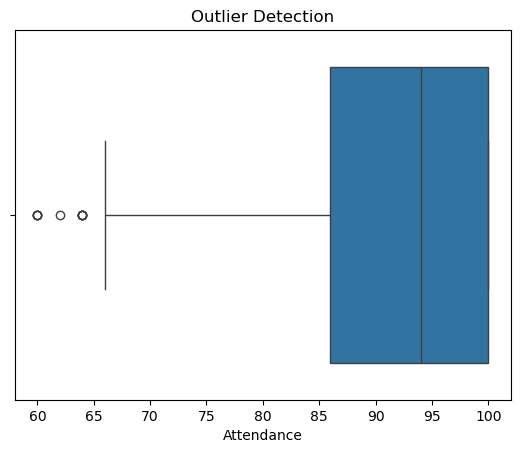

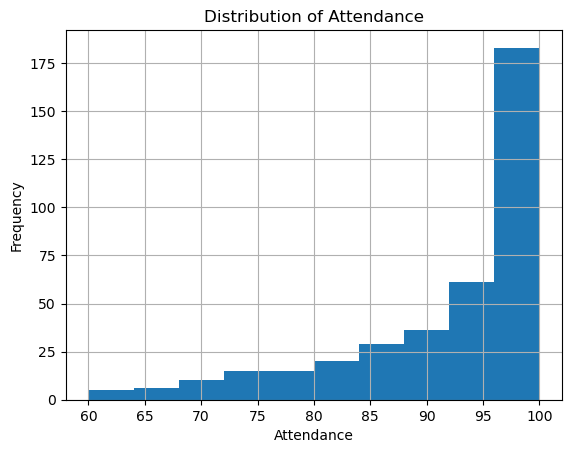

,Student_ID,Study_Hours,Attendance,Sleep_Hours,Previous_Marks,Assignments_Completed,Distraction_Time,Current_Score,Target_Score
count,380.000000,3.800000e+02,380.000000,380.000000,3.800000e+02,380.000000,380.000000,3.800000e+02,380.000000
mean,196.915789,1.963342e-16,90.794737,7.571053,1.799730e-16,9.673684,6.365789,7.479397e-17,20.421053
std,114.950939,1.001318e+00,9.936472,1.381256,1.001318e+00,0.747091,1.667757,1.001318e+00,4.612313
min,1.000000,-1.250182e+00,60.000000,5.000000,-2.846301e+00,7.000000,2.000000,-2.262377e+00,10.000000
25%,97.750000,-1.250182e+00,86.000000,7.000000,-4.575036e-01,10.000000,5.000000,-5.256027e-01,18.000000
50%,194.500000,-5.953247e-02,94.000000,8.000000,7.334028e-02,10.000000,6.000000,1.256876e-01,21.000000
75%,296.250000,-5.953247e-02,100.000000,9.000000,6.041842e-01,10.000000,8.000000,7.769780e-01,24.000000
max,395.000000,2.321766e+00,100.000000,9.000000,2.196716e+00,10.000000,10.000000,2.079559e+00,30.000000


In [7]:
import seaborn as sb
from sklearn.preprocessing import StandardScaler

dataset=df_final.copy()

#handle missing values
dataset['Study_Hours'].fillna(dataset['Study_Hours'].median(), inplace=True)
dataset['Distraction_Time'].fillna(dataset['Distraction_Time'].median(), inplace=True)

#outlier detection
Q1=dataset['Attendance'].quantile(0.25)
Q3=dataset['Attendance'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
dataset=dataset[(dataset['Attendance']>=lower) & (dataset['Attendance']<=upper)]

#standardization for k-means clustering (mean=0, standard deviation=1)
scaler = StandardScaler()
dataset[['Study_Hours', 'Previous_Marks', 'Current_Score']] = scaler.fit_transform(dataset[['Study_Hours', 'Previous_Marks', 'Current_Score']])

print("The dataset after cleaning transformation: ")
sb.boxplot(x=dataset["Attendance"])
plt.title("Outlier Detection")
plt.show()

dataset["Attendance"].hist()
plt.title("Distribution of Attendance")
plt.xlabel("Attendance")
plt.ylabel("Frequency")
plt.show()
dataset.describe()

In [11]:
#k-means clustering to divide the data into 3 groups: easy, meadium, hard subject difficulty
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
dataset['Cluster'] = kmeans.fit_predict(dataset[['Study_Hours', 'Previous_Marks', 'Current_Score']])

cluster_means = dataset.groupby('Cluster')['Current_Score'].mean()

sorted_clusters = cluster_means.sort_values()

difficulty_map = {sorted_clusters.index[0]: 'Hard', sorted_clusters.index[1]: 'Medium', sorted_clusters.index[2]: 'Easy'}

dataset['Subject_Difficulty'] = dataset['Cluster'].map(difficulty_map)

dataset.drop('Cluster', axis=1, inplace=True)

print(dataset.head())

   Student_ID  Study_Hours  Attendance  Sleep_Hours  Previous_Marks  \
0           1    -0.059532          88            7       -1.253770   
1           2    -0.059532          92            7       -1.519191   
2           3    -0.059532          80            7       -0.722926   
3           4     1.131117          96            9        0.869606   
4           5    -0.059532          92            9       -0.192082   

   Assignments_Completed  Distraction_Time  Current_Score  Target_Score  \
0                     10               7.0      -0.959796            16   
1                     10               6.0      -0.959796            16   
2                      7               5.0      -0.091409            20   
3                     10               4.0       0.994075            25   
4                     10               5.0      -0.091409            20   

  Subject_Difficulty  
0               Hard  
1               Hard  
2               Easy  
3               Easy  
4      

C:\Users\Pratyaksh Tiwari\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [30]:
#replacing the standardized values with original values
dataset[['Study_Hours', 'Previous_Marks', 'Current_Score']]=df_final[['Study_Hours', 'Previous_Marks', 'Current_Score']]
print(dataset.head())

   Student_ID  Study_Hours  Attendance  Sleep_Hours  Previous_Marks  \
0           1          4.0          88            7               6   
1           2          4.0          92            7               5   
2           3          4.0          80            7               8   
3           4          6.0          96            9              14   
4           5          4.0          92            9              10   

   Assignments_Completed  Distraction_Time  Current_Score  Target_Score  \
0                     10               7.0              6            16   
1                     10               6.0              6            16   
2                      7               5.0             10            20   
3                     10               4.0             15            25   
4                     10               5.0             10            20   

   Predicted_Current_Score  
0                     6.04  
1                     5.85  
2                     9.67  
3     

In [31]:
#training random forest model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = dataset[['Study_Hours', 'Attendance', 'Sleep_Hours', 'Previous_Marks', 'Assignments_Completed', 'Distraction_Time']]

y = dataset['Current_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)    #20% data for testing and 80% for training with seeding to fix radomly chosen data

model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
#testing model
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 0.8999649122807017


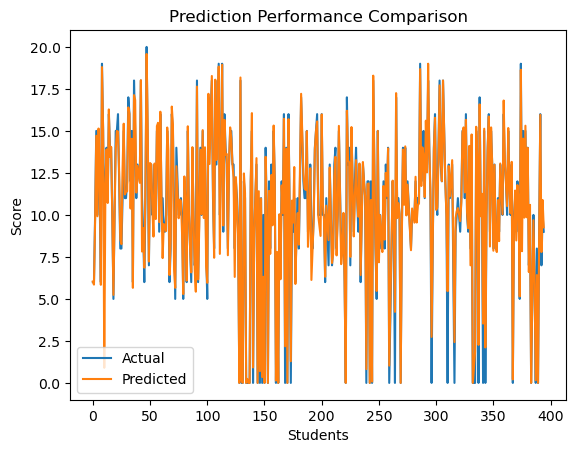

In [26]:
dataset['Predicted_Current_Score'] = model.predict(X)
plt.figure()

plt.plot(dataset['Current_Score'], label='Actual')
plt.plot(dataset['Predicted_Current_Score'], label='Predicted')

plt.legend()
plt.title("Prediction Performance Comparison")
plt.xlabel("Students")
plt.ylabel("Score")

plt.show()

In [27]:
def generate_plan(row, model):
    
    best_score = row['Predicted_Current_Score']
    best_plan = row.copy()
    target = row['Target_Score']
    
    for hours in range(int(row['Study_Hours']), int(row['Study_Hours']) + 4):
        for distraction in range(max(0, int(row['Distraction_Time']) - 3), int(row['Distraction_Time']) + 1):
            
            temp = row.copy()
            temp['Study_Hours'] = hours
            temp['Distraction_Time'] = distraction
            temp['Assignments_Completed'] += 1
            temp['Attendance'] = min(100, temp['Attendance'] + 2)
            temp['Sleep_Hours'] = max(6, temp['Sleep_Hours'])
            
            features_df = pd.DataFrame([[
                temp['Study_Hours'],
                temp['Attendance'],
                temp['Sleep_Hours'],
                temp['Previous_Marks'],
                temp['Assignments_Completed'],
                temp['Distraction_Time']
            ]], columns=X.columns)
            
            predicted = model.predict(features_df)[0]
            
            if abs(target - predicted) < abs(target - best_score):
                best_score = predicted
                best_plan = temp.copy()
    
    return best_plan, best_score

In [28]:
def print_study_plan(row, best_plan, best_score):
    
    print("\n" + "_"*60)
    print("| {:<20} | {:<15} | {:<15} |".format("Feature", "Current", "Planned"))
    print("|" + "_"*22 + "|" + "_"*17 + "|" + "_"*17 + "|")
    
    cols = ['Study_Hours', 'Attendance', 'Sleep_Hours',
            'Assignments_Completed', 'Distraction_Time']
    
    for col in cols:
        print("| {:<20} | {:<15} | {:<15} |".format(
            col,
            round(row[col],2),
            round(best_plan[col],2)
        ))
    
    print("|" + "_"*22 + "|" + "_"*17 + "|" + "_"*17 + "|")
    
    print("| {:<20} | {:<15} | {:<15} |".format(
        "Predicted Score",
        round(row['Predicted_Current_Score'],2),
        round(best_score,2)
    ))
    
    print("| {:<20} | {:<15} | {:<15} |".format(
        "Target Score",
        row['Target_Score'],
        row['Target_Score']
    ))
    
    print("|" + "_"*60 + "|")

In [33]:
dataset.describe()

,Student_ID,Study_Hours,Attendance,Sleep_Hours,Previous_Marks,Assignments_Completed,Distraction_Time,Current_Score,Target_Score,Predicted_Current_Score
count,380.000000,377.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,196.915789,4.100796,90.794737,7.571053,10.723684,9.673684,6.365789,10.421053,20.421053,10.414693
std,114.950939,1.688643,9.936472,1.381256,3.772553,0.747091,1.667757,4.612313,4.612313,4.484857
min,1.000000,2.000000,60.000000,5.000000,0.000000,7.000000,2.000000,0.000000,10.000000,0.000000
25%,97.750000,2.000000,86.000000,7.000000,9.000000,10.000000,5.000000,8.000000,18.000000,8.085000
50%,194.500000,4.000000,94.000000,8.000000,11.000000,10.000000,6.000000,11.000000,21.000000,10.748333
75%,296.250000,4.000000,100.000000,9.000000,13.000000,10.000000,8.000000,14.000000,24.000000,13.427500
max,395.000000,8.000000,100.000000,9.000000,19.000000,10.000000,10.000000,20.000000,30.000000,19.580000


In [38]:
study_hour=int(input("Enter study hours: "))
attend=int(input("Enter attendance percentage: "))
sleep_hour=int(input("Enter sleep hours: "))
previous_mark=int(input("Enter previous marks: "))
assignment_done=int(input("Enter assignments completed: "))
distract_time=int(input("Enter distraction time: "))

student = pd.DataFrame([{
    'Study_Hours': study_hour,
    'Attendance': attend,
    'Sleep_Hours': sleep_hour,
    'Previous_Marks': previous_mark,
    'Assignments_Completed': assignment_done,
    'Distraction_Time': distract_time
}])

pred_score = model.predict(student)[0]

student['Predicted_Current_Score'] = pred_score

target_score=int(input("Enter target score: "))
student['Target_Score'] = target_score

row = student.iloc[0]
best_plan, best_score = generate_plan(row, model)

print("The study plan for the student:")
print_study_plan(row, best_plan, best_score)

Enter study hours:  4
Enter attendance percentage:  87
Enter sleep hours:  8
Enter previous marks:  19
Enter assignments completed:  6
Enter distraction time:  6
Enter target score:  20


The study plan for the student:

____________________________________________________________
| Feature              | Current         | Planned         |
|______________________|_________________|_________________|
| Study_Hours          | 4.0             | 7.0             |
| Attendance           | 87.0            | 89.0            |
| Sleep_Hours          | 8.0             | 8.0             |
| Assignments_Completed | 6.0             | 7.0             |
| Distraction_Time     | 6.0             | 3.0             |
|______________________|_________________|_________________|
| Predicted Score      | 18.86           | 19.11           |
| Target Score         | 20.0            | 20.0            |
|____________________________________________________________|
